# 7. Мини-проект. Практика

Мы рассмотрим две задачи: регрессию и классификацию. Затем мы сравним результаты байесовских методов с результатами работы линейных моделей. 

Посмотрите скринкаст с разбором задачи по построению байесовского классификатора в задаче определения уровня зарплаты

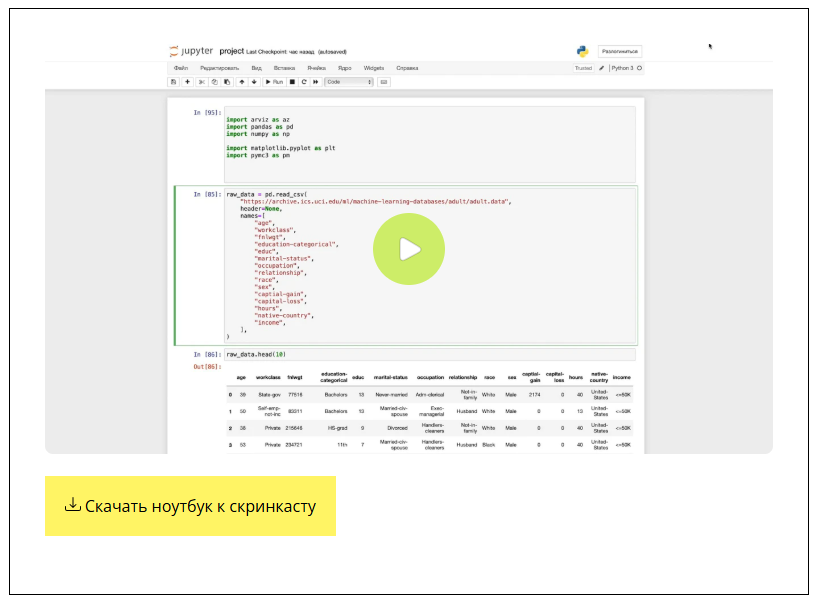

Вам будет необходимо загрузить датасет с данными о квартирах и их стоимости  для решения задачи регрессии. 

Сделайте первичный анализ, подготовьте признаки, которые будете использовать и проанализируйте их распределения. Лучше работать с целевой переменной, применив к ней логарифм (посмотрите на получившееся распределение!). После предсказания значение можно будет перевести обратно, сделав степенью экспоненты.

Сделайте модель байесовской линейной регрессии с выбранными признаками.

На тех же самых признаках постройте линейную регрессию из sklearn и сравните получившиеся коэффициенты классической линейной регрессии с коэффициентами при признаках в байесовской линейной регрессии (при помощи pm.summary(trace)).  

Совпадают ли коэффициенты? Может быть, они по крайней мере очень похожи?

## Критерии оценивания:

2 балла	Есть минимальный анализ данных, анализ распределений признаков.

4 балла	Построена модель байесовской линейной регрессии с выбранными признаками.

3 балла	На выбранных признаках (признаки в байесовской лин. регрессии и в этой лин. регрессии должны совпадать) построена линейная регрессия из sklearn.

1 балл	Сравнение получившихся коэффициентов классической линейной регрессии с коэффициентами при признаках в байесовской линейной регрессии (есть pm.summary(trace) и вывод коэффициентов классической линейной регрессии).

# Homework

Импортируем бибилиотеки

In [11]:
import theano
import arviz as az
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pymc3 as pm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

theano.config.cxx = ""
theano.config.mode = "FAST_COMPILE"

Прочитаем данные недвижимости

In [12]:
df = pd.read_csv('data/flats.csv')
df.head(3)

,Unnamed: 0,price_doc,full_sq,life_sq,num_room,kitch_sq
0,8056,2750000,11,11.0,1.0,12.0
1,8154,7100000,45,27.0,2.0,6.0
2,8287,11700000,77,50.0,3.0,8.0


## 7.1. анализ данных, анализ распределений признаков

Размер датасета: 6042 строк, 6 столбцов


,Unnamed: 0,price_doc,full_sq,life_sq,num_room,kitch_sq
0,8056,2750000,11,11.0,1.0,12.0
1,8154,7100000,45,27.0,2.0,6.0
2,8287,11700000,77,50.0,3.0,8.0
3,8387,10400000,56,29.0,2.0,10.0
4,8391,6200000,31,21.0,1.0,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6042 entries, 0 to 6041
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6042 non-null   int64  
 1   price_doc   6042 non-null   int64  
 2   full_sq     6042 non-null   int64  
 3   life_sq     6042 non-null   float64
 4   num_room    6042 non-null   float64
 5   kitch_sq    6042 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 283.3 KB

Пропуски по столбцам:


,missing_count,missing_percent



Числовые признаки: ['Unnamed: 0', 'price_doc', 'full_sq', 'life_sq', 'num_room', 'kitch_sq']


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,6042.0,1.984699e+04,6.081011e+03,8056.0,14573.25,19871.5,25147.75,30470.0
price_doc,6042.0,8.750423e+06,6.277290e+06,500000.0,5800000.00,7400000.0,10500000.00,95122496.0
full_sq,6042.0,5.337454e+01,2.401194e+01,1.0,38.00,46.0,63.00,637.0
life_sq,6042.0,3.319894e+01,2.019000e+01,0.0,20.00,29.0,42.00,637.0
num_room,6042.0,1.997021e+00,8.895228e-01,0.0,1.00,2.0,3.00,17.0
kitch_sq,6042.0,7.391096e+00,3.806198e+00,0.0,5.00,7.0,9.00,96.0



Целевая переменная для анализа распределения: price_doc


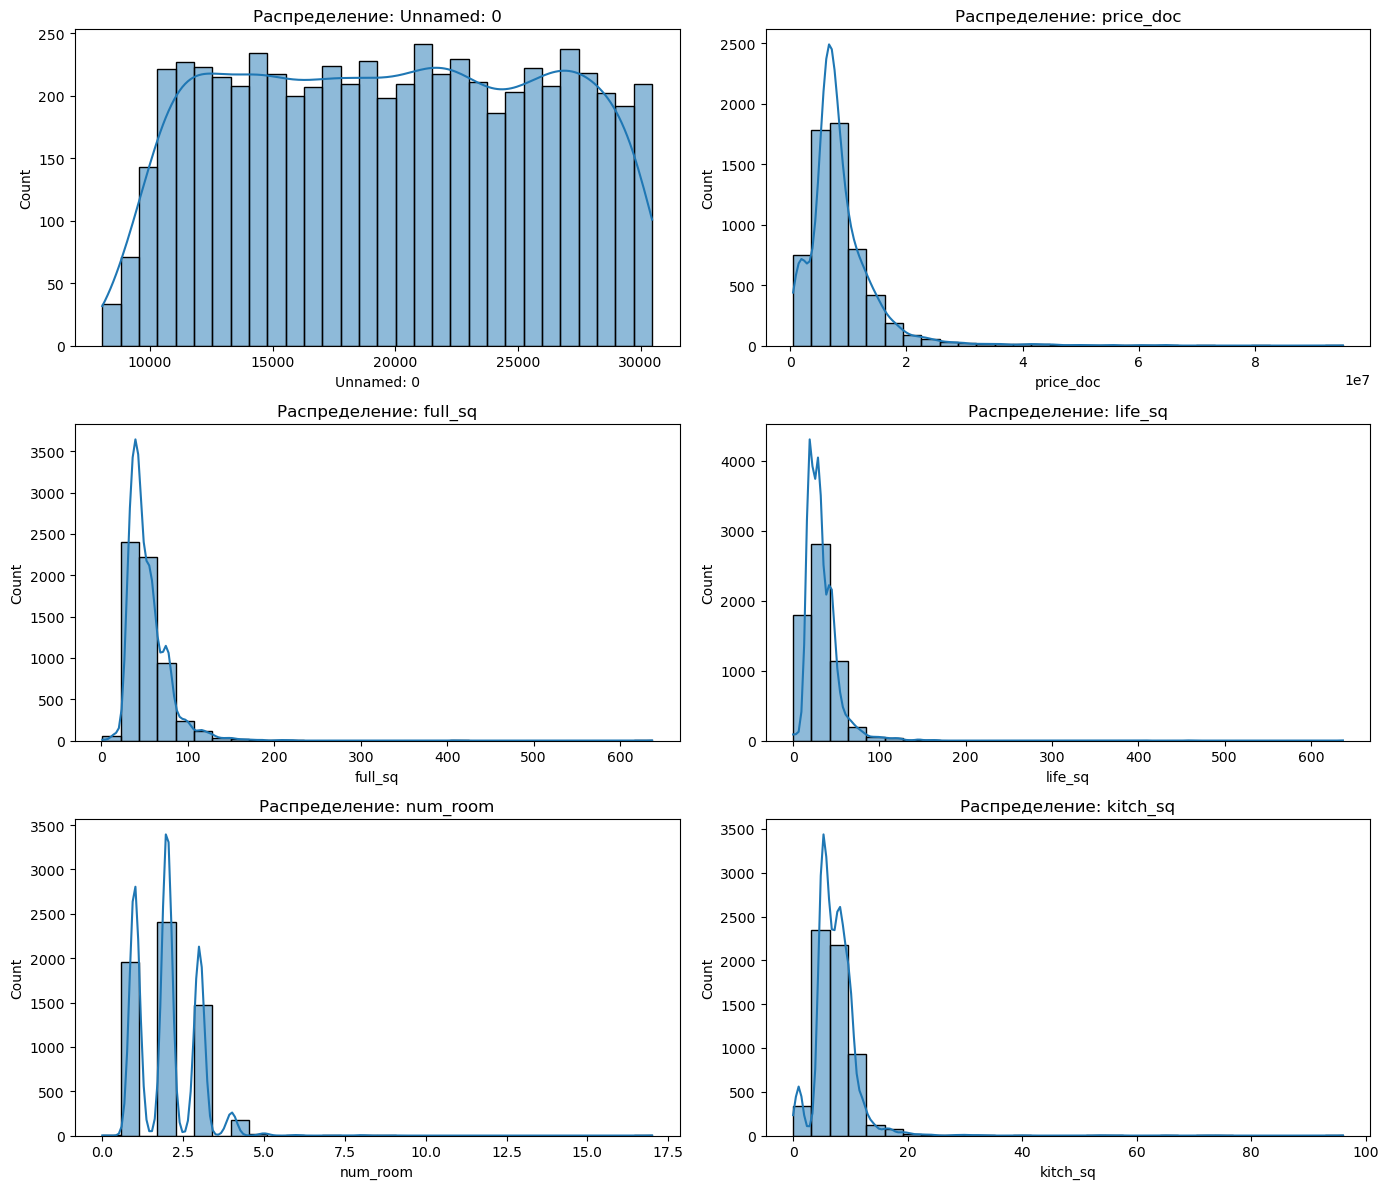

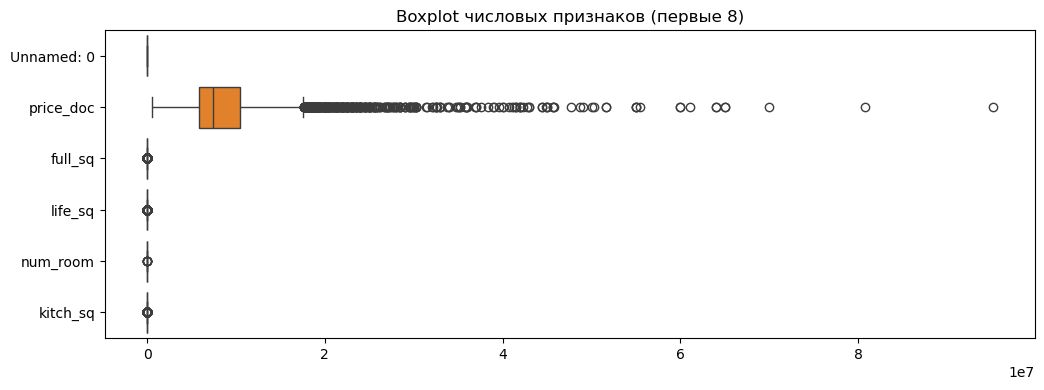

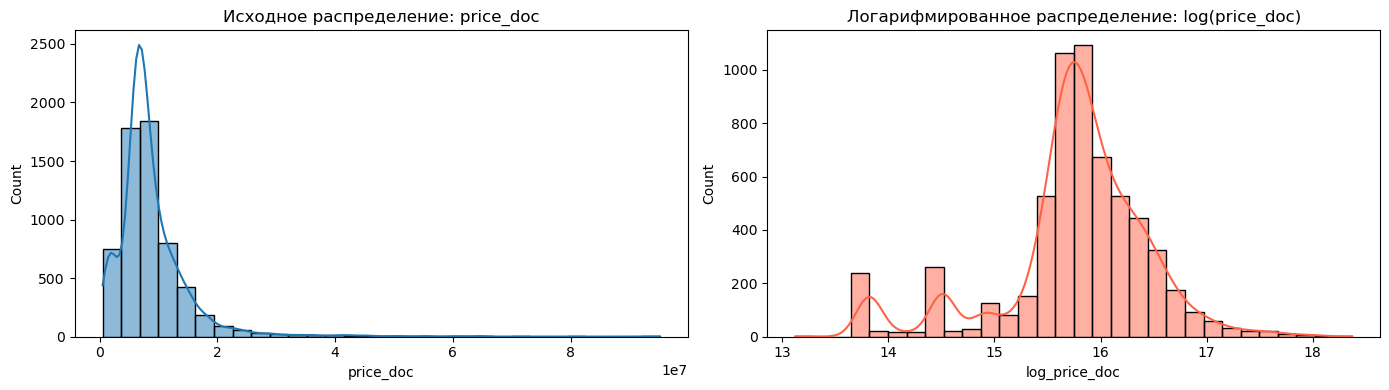

In [13]:
# 1) Общий обзор датасета
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
display(df.head())
df.info()

# 2) Пропуски
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
})

print("\nПропуски по столбцам:")
display(missing_table[missing_table['missing_count'] > 0])

# 3) Базовые статистики по числовым признакам
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("\nЧисловые признаки:", num_cols)
display(df[num_cols].describe().T)

# 4) Анализ распределений (гистограммы + boxplot)
# Целевая переменная: сначала ищем типичные названия цены.
target_candidates = ['price_doc', 'price', 'target', 'y']
target_col = next((col for col in target_candidates if col in df.columns), None)
if target_col is None:
    # Фолбэк: если явной цели нет, берем последний числовой столбец.
    target_col = num_cols[-1]

print(f"\nЦелевая переменная для анализа распределения: {target_col}")

# Берем до 8 числовых признаков, чтобы графики оставались читабельными.
plot_cols = num_cols[:8]
if target_col not in plot_cols and target_col in num_cols:
    plot_cols = ([target_col] + [c for c in plot_cols if c != target_col])[:8]

n = len(plot_cols)
rows = int(np.ceil(n / 2))
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Распределение: {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Boxplot для выявления выбросов
plt.figure(figsize=(12, 4))
sns.boxplot(data=df[plot_cols], orient='h')
plt.title('Boxplot числовых признаков (первые 8)')
plt.show()

# 5) Логарифм целевой переменной (рекомендация из задания)
# Используем log1p для устойчивости к возможным нулям.
if (df[target_col] >= 0).all():
    df['log_' + target_col] = np.log1p(df[target_col])
else:
    # Если есть отрицательные значения, сдвигаем ряд перед логарифмированием.
    shift = abs(df[target_col].min()) + 1
    df['log_' + target_col] = np.log(df[target_col] + shift)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[target_col].dropna(), kde=True, ax=ax[0], bins=30)
ax[0].set_title(f'Исходное распределение: {target_col}')

sns.histplot(df['log_' + target_col].dropna(), kde=True, ax=ax[1], bins=30, color='tomato')
ax[1].set_title(f'Логарифмированное распределение: log({target_col})')
plt.tight_layout()
plt.show()

Выводы 7.1:

- Провел быстрый EDA
- Проверены пропуски по всем столбцам
- Посчитана статистика по числовым признакам
- Построены гистограммы распределений признаков и boxplot для оценки выбросов.
- Анализ целевой переменной с распределениями "исходное" и "логарифмированное распределение"

price_doc имеет выраженную правостороннюю асимметрию и длинный хвост. После логарифмирования распределение заметно ближе к нормальному, что подходит для дальнейшей регрессии.

## 7.2 модель байесовской линейной регрессии с выбранными признаками.

The glm module is deprecated and will be removed in version 4.0
We recommend to instead use Bambi https://bambinos.github.io/bambi/
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: divide by zero encountered in log
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: invalid value encountered in multiply
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
Sequential sampling (2 chains in 1 job)
NUTS: [sd, kitch_sq_z, num_room_z, life_sq_z, full_sq_z, Intercept]


c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: overflow encountered in exp
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: divide by zero encountered in true_divide
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: overflow encountered in power
  variables = ufunc(*ufunc_args, **ufunc_kwargs)


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 290 seconds.
Got error No model on context stack. trying to find log_likelihood in translation.


Формула модели: log_price_doc ~ full_sq_z + life_sq_z + num_room_z + kitch_sq_z
Размер обучающей выборки: (6041, 10)


c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,15.774,0.008,15.760,15.790,0.000,0.000,1860.0,1395.0,1.00
full_sq_z,0.318,0.019,0.284,0.354,0.001,0.001,633.0,863.0,1.00
life_sq_z,-0.067,0.016,-0.098,-0.039,0.001,0.000,701.0,1063.0,1.01
num_room_z,0.089,0.011,0.070,0.111,0.000,0.000,1301.0,1152.0,1.00
kitch_sq_z,0.050,0.009,0.033,0.065,0.000,0.000,1108.0,1186.0,1.00
sd,0.597,0.006,0.586,0.607,0.000,0.000,2129.0,1515.0,1.00


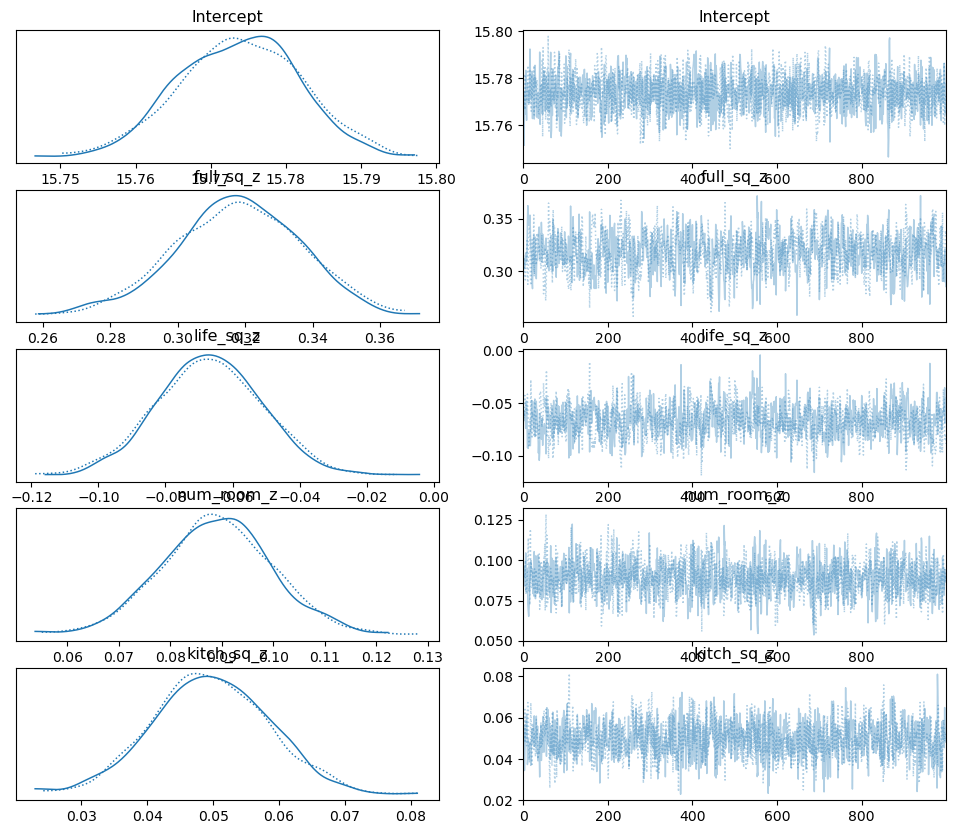

In [14]:
# Подготовка данных для байесовской линейной регрессии
selected_features = ['full_sq', 'life_sq', 'num_room', 'kitch_sq']

reg_data = df[selected_features + ['price_doc']].copy()
reg_data = reg_data.dropna()

# Убираем заведомо некорректные значения площадей/комнат
reg_data = reg_data[(reg_data['full_sq'] > 0) & (reg_data['life_sq'] >= 0) & (reg_data['num_room'] > 0) & (reg_data['kitch_sq'] >= 0)]

# Логарифм целевой переменной (как рекомендовано в задании)
reg_data['log_price_doc'] = np.log1p(reg_data['price_doc'])

# Стандартизация признаков помогает более стабильной сходимости MCMC
for col in selected_features:
    reg_data[col + '_z'] = (reg_data[col] - reg_data[col].mean()) / reg_data[col].std()

formula = 'log_price_doc ~ full_sq_z + life_sq_z + num_room_z + kitch_sq_z'

with pm.Model() as bayes_lm:
    pm.glm.GLM.from_formula(formula, reg_data, family=pm.glm.families.Normal())
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        random_seed=42,
        target_accept=0.9,
        return_inferencedata=False
    )

print('Формула модели:', formula)
print('Размер обучающей выборки:', reg_data.shape)

# Трейс коэффициентов
az.plot_trace(trace, var_names=['Intercept', 'full_sq_z', 'life_sq_z', 'num_room_z', 'kitch_sq_z']);

# Сводка параметров модели
pm.summary(trace)

### Вывод по модели 7.2

Построена байесовская линейная регрессия для целевой переменной `log_price_doc` на признаках `full_sq`, `life_sq`, `num_room`, `kitch_sq` (в стандартизованном виде).

По результатам `pm.summary(trace)`:

- `Intercept` = **15.774**
- `full_sq_z` = **+0.318**
- `life_sq_z` = **-0.067**
- `num_room_z` = **+0.089**
- `kitch_sq_z` = **+0.050**

Краткий Вывод:

- Наибольший положительный вклад в лог-цену вносит `full_sq_z`.
- `num_room_z` и `kitch_sq_z` также положительно связаны с ценой, но слабее.
- `life_sq_z` имеет небольшой отрицательный коэффициент в присутствии других признаков (возможна мультиколлинеарность с `full_sq`).

Качество сходимости:

- `r_hat` для параметров около **1.00-1.01**, что указывает на хорошую сходимость цепей.
- В ходе семплирования не наблюдалось дивергенций (`0 divergences`).

Итог: модель байесовской линейной регрессии корректно обучена , можно сравнить с классической линейной регрессией из `sklearn`.

## 7.3 На выбранных признаках (как в байесовской линейной регрессии) построить линейную регрессия из sklearn.

In [15]:
# Используем те же признаки и тот же таргет, что и в байесовской линейной регрессии
X = reg_data[['full_sq_z', 'life_sq_z', 'num_room_z', 'kitch_sq_z']]
y = reg_data['log_price_doc']

lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred = lin_reg.predict(X)

print('Линейная регрессия sklearn обучена на тех же признаках, что и байесовская модель.')
print('\nКоэффициенты sklearn LinearRegression:')
print(f"Intercept: {lin_reg.intercept_:.6f}")
for feature, coef in zip(X.columns, lin_reg.coef_):
    print(f"{feature}: {coef:.6f}")

print('\nМетрики на обучающей выборке (log-таргет):')
print(f"R2: {r2_score(y, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")

coef_sklearn = pd.DataFrame({
    'feature': ['Intercept'] + list(X.columns),
    'coef_sklearn': [lin_reg.intercept_] + list(lin_reg.coef_)
})

display(coef_sklearn)

Линейная регрессия sklearn обучена на тех же признаках, что и байесовская модель.

Коэффициенты sklearn LinearRegression:
Intercept: 15.773777
full_sq_z: 0.317319
life_sq_z: -0.066582
num_room_z: 0.088933
kitch_sq_z: 0.049689

Метрики на обучающей выборке (log-таргет):
R2: 0.2580
MAE: 0.3897
RMSE: 0.5963


,feature,coef_sklearn
0,Intercept,15.773777
1,full_sq_z,0.317319
2,life_sq_z,-0.066582
3,num_room_z,0.088933
4,kitch_sq_z,0.049689


### Вывод по модели 7.3 (LinearRegression, sklearn)

Построена классическая линейная регрессия `sklearn` на тех же признаках, что и байесовская модель:
`full_sq_z`, `life_sq_z`, `num_room_z`, `kitch_sq_z`.

Полученные коэффициенты:

- `Intercept`: **15.773777**
- `full_sq_z`: **0.317319**
- `life_sq_z`: **-0.066582**
- `num_room_z`: **0.088933**
- `kitch_sq_z`: **0.049689**

Метрики на обучающей выборке (для `log_price_doc`):

- `R2`: **0.2580**
- `MAE`: **0.3897**
- `RMSE`: **0.5963**

Итог:

- Линейная модель успешно обучена на тех же признаках, что и байесовская регрессия.
- Знаки и масштабы коэффициентов согласуются с байесовской моделью.

## 7.4 Сравнение получившихся коэффициентов классической линейной регрессии с коэффициентами при признаках в байесовской линейной регрессии (есть pm.summary(trace) и вывод коэффициентов классической линейной регрессии).

In [16]:
# Коэффициенты байесовской модели из pm.summary(trace)
bayes_summary = pm.summary(trace)

coef_bayes = (
    bayes_summary
    .loc[['Intercept', 'full_sq_z', 'life_sq_z', 'num_room_z', 'kitch_sq_z'], ['mean']]
    .rename(columns={'mean': 'coef_bayes'})
    .reset_index()
    .rename(columns={'index': 'feature'})
)

# Коэффициенты классической линейной регрессии
coef_sklearn = pd.DataFrame({
    'feature': ['Intercept'] + list(X.columns),
    'coef_sklearn': [lin_reg.intercept_] + list(lin_reg.coef_)
})

# Сравнение коэффициентов
coef_compare = coef_bayes.merge(coef_sklearn, on='feature', how='inner')
coef_compare['abs_diff'] = (coef_compare['coef_bayes'] - coef_compare['coef_sklearn']).abs()
coef_compare['rel_diff_pct'] = (
    coef_compare['abs_diff'] / coef_compare['coef_bayes'].abs().replace(0, np.nan) * 100
).round(3)

print('Сравнение коэффициентов Bayesian Linear Regression и sklearn LinearRegression:')
display(coef_compare)

mean_abs_diff = coef_compare['abs_diff'].mean()
max_abs_diff = coef_compare['abs_diff'].max()

print(f'\nСредняя абсолютная разница коэффициентов: {mean_abs_diff:.6f}')
print(f'Максимальная абсолютная разница коэффициентов: {max_abs_diff:.6f}')

if max_abs_diff < 0.01:
    print('Вывод: коэффициенты практически совпадают.')
elif max_abs_diff < 0.05:
    print('Вывод: коэффициенты очень близки.')
else:
    print('Вывод: есть заметные различия, стоит проверить спецификацию модели и параметры семплирования.')

Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\tgorbunov\AppData\Local\anaconda3\envs\pymc3_virt\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Сравнение коэффициентов Bayesian Linear Regression и sklearn LinearRegression:


,feature,coef_bayes,coef_sklearn,abs_diff,rel_diff_pct
0,Intercept,15.774,15.773777,0.000223,0.001
1,full_sq_z,0.318,0.317319,0.000681,0.214
2,life_sq_z,-0.067,-0.066582,0.000418,0.623
3,num_room_z,0.089,0.088933,0.000067,0.076
4,kitch_sq_z,0.050,0.049689,0.000311,0.621



Средняя абсолютная разница коэффициентов: 0.000340
Максимальная абсолютная разница коэффициентов: 0.000681
Вывод: коэффициенты практически совпадают.


### Вывод по заданию 7.4

Сравнение коэффициентов байесовской линейной регрессии и `sklearn.LinearRegression` на одинаковых признаках показало, что оценки практически совпадают.

Ключевые результаты:

- средняя абсолютная разница коэффициентов: **0.000340**;
- максимальная абсолютная разница: **0.000681**.

Следовательно, коэффициенты классической линейной регрессии и коэффициенты при признаках в байесовской линейной регрессии совпадают с очень высокой точностью (различия на уровне округления).